# 08 — External Validation on the Winning Arguments (WA) Dataset

The prior analysis on this project's own dataset established that comment length is the dominant predictor of persuasion, that the 8 rhetorical-strategy scores add a real signal on top of it, and that this signal survives length control far better than length itself does — with `refutation` as the most consistent individual strategy and `justification` showing a strong-before/weak-after-length-control pattern.

This notebook checks whether those findings generalize to an independent dataset: the Winning Arguments (WA) corpus (Tan, Niculae, Danescu-Niculescu-Mizil & Lee, 2016, *Winning Arguments: Interpreting and Predicting Persuasiveness in Resource-Constrained Online Discussions*), the same benchmark used by Labruna, Modzelewski, Satta & Da San Martino (2026) for the Multi-Strategy Persuasion Scoring (MS-PS) method this project adapts. This is a generalization check, not a new optimization pass: the same 8-strategy rubric, the same Gemini prompt, the same fixed model architecture, and the same `word_count` definition already settled in `05`/`06`/`07` are applied here unchanged — no feature selection or tuning against WA.

Specifically, this notebook asks:
1. Do the 8 strategy scores add information beyond `word_count` on WA too?
2. Does `refutation` remain the standout, most-consistent strategy?
3. Does `justification` again look strong before length control and weaken after?
4. Does the reduced model (`refutation` + `justification` + `simplification` + `word_count`) stay competitive?
5. Does the strategy effect hold up under a length-control check, if WA's structure allows one?


## Data: The Winning Arguments Corpus

WA pairs a successful reply to a CMV original post (one that was awarded a delta) with an unsuccessful reply to the *same* original post, chosen as the most topically similar (Jaccard similarity) reply that did not win a delta. Each pair is a controlled, within-thread comparison: same original post, similar topic, different outcome.

The corpus is distributed through [ConvoKit](https://convokit.cornell.edu/documentation/winning.html) (`pip install convokit`), which downloads and caches it locally (`~/.convokit/saved-corpora/winning-args-corpus/`, outside this repo, the same convention this project already uses for raw Reddit data). Only ConvoKit's download helper is used here — the files are parsed directly as JSON rather than loaded into ConvoKit's own `Corpus` object, which pulls in a much heavier dependency tree (spaCy, sentence-transformers, etc.) than this notebook needs.

Each conversation in the download carries `op-title`/`op-text-body` (the original post) and a `train`/`heldout` flag; each reply carries `success` (1 = won a delta and is the designated winner of a pair, 0 = the matched loser, missing = not part of any pair) and `pair_ids`. This corpus edition already *is* the pair-task subset — every one of its 3,051 conversations contains at least one pair, totalling exactly 4,263 pairs, matching the split size reported in the literature (3,456 train + 807 heldout).

In [1]:
import warnings
warnings.filterwarnings('ignore')  # a bottleneck/numpy ABI warning fires on convokit's pandas import - harmless, silenced for readability

from convokit import download

WA_CORPUS_PATH = download('winning-args-corpus')
print(f'Corpus cached at: {WA_CORPUS_PATH}')



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/dikla/Documents/Private/study/change-my-view-2025/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/dikla/Documents/Private/study/change-my-view-2025/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/dikla/Documents/Private/study/change-my-view-2025/.ve

AttributeError: _ARRAY_API not found

Done
Corpus cached at: /Users/dikla/.convokit/saved-corpora/winning-args-corpus


In [2]:
import json
import os

import pandas as pd

def normalize_newlines(text):
    # Bare \r (not part of \r\n) embedded in text can break pandas' C CSV parser
    # intermittently (misread as a row terminator depending on chunk boundaries) - normalize
    # everything to \n up front, before this text enters any checkpoint or output file.
    return str(text).replace('\r\n', '\n').replace('\r', '\n')

with open(os.path.join(WA_CORPUS_PATH, 'conversations.json')) as f:
    wa_conversations = json.load(f)

op_lookup = {}
train_flag = {}
for conv_id, conv in wa_conversations.items():
    meta = conv.get('meta', conv)
    op_lookup[conv_id] = normalize_newlines(str(meta['op-title']) + '\n' + str(meta['op-text-body']))
    train_flag[conv_id] = meta['train']

print(f'{len(wa_conversations)} conversations loaded')
print(f'train-flagged: {sum(v == 1 for v in train_flag.values())}, '
      f'heldout-flagged: {sum(v == 0 for v in train_flag.values())}')


3051 conversations loaded
train-flagged: 2509, heldout-flagged: 542


Each conversation can have multiple pairs — up to 17 in the largest one (a popular thread with several distinct winning/losing argument pairs). The unit of analysis kept below is the **direct top-level reply to the original post** on each side of a pair (not deeper nested replies within a "winning thread"), matching the original paper's framing of comparing two arguments made directly in response to the same post. A handful of utterances serve as a direct reply for more than one pair (the same comment was the closest topical match to two different winning threads); these are kept once, as a single row, rather than duplicated per pair.

In [3]:
wa_rows = {}  # keyed by utterance id, so a comment reused across pairs is kept once
with open(os.path.join(WA_CORPUS_PATH, 'utterances.jsonl')) as f:
    for line in f:
        u = json.loads(line)
        meta = u['meta']
        if meta['success'] is None:
            continue
        if u['reply-to'] != u['root']:
            continue  # not a direct top-level reply to the original post
        wa_rows[u['id']] = {
            'comment_id': u['id'],
            'op_id': u['root'],
            'pair_id': meta['pair_ids'][0],
            'original_post': op_lookup[u['root']],
            'thread_text': '',
            'final_comment': normalize_newlines(u['text']),
            'is_convincing': meta['success'],
            'split': 'train' if train_flag[u['root']] == 1 else 'heldout',
        }

wa_df = pd.DataFrame(wa_rows.values()).reset_index(drop=True)
print(f'{len(wa_df)} comments across {wa_df["op_id"].nunique()} original posts')
print(wa_df.groupby('split')['is_convincing'].agg(['count', 'mean']))


8106 comments across 3051 original posts
         count      mean
split                   
heldout   1516  0.529024
train     6590  0.521700


In [4]:
# Sanity checks before doing anything else with this data
assert wa_df['comment_id'].is_unique
assert wa_df['final_comment'].str.strip().ne('').all()
assert wa_df['original_post'].str.strip().ne('').all()
assert set(wa_df['is_convincing'].unique()) == {0, 1}
assert set(wa_df['split'].unique()) == {'train', 'heldout'}

# Every original post with a pair contributes both a winner and a loser among these direct replies
per_op = wa_df.groupby('op_id')['is_convincing'].agg(['sum', 'count'])
assert (per_op['sum'] >= 1).all() and ((per_op['count'] - per_op['sum']) >= 1).all()

print('All checks passed.')
print(f'Overall positive rate: {wa_df["is_convincing"].mean():.3f}')


All checks passed.
Overall positive rate: 0.523


## Feature Preparation — `word_count`

Same definition as `04.3`/`06`/`07`: word count on the same cleaned-text pipeline TF-IDF and the engineered features use elsewhere in this project (digits, punctuation, single letters and URLs stripped first), reusing `02_data_annotation.ipynb`'s `clean_text` unchanged.

In [5]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'\b\d\b', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]\b', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    return text

wa_df['cleaned_final_comment'] = wa_df['final_comment'].apply(clean_text)
wa_df['word_count'] = wa_df['cleaned_final_comment'].apply(lambda s: len(s.split()))

print(wa_df['word_count'].describe())


count    8106.000000
mean      236.231804
std       196.947434
min        42.000000
25%       107.000000
50%       175.000000
75%       295.750000
max      1663.000000
Name: word_count, dtype: float64


In [6]:
from scipy.stats import pointbiserialr

r, p = pointbiserialr(wa_df['is_convincing'], wa_df['word_count'])
print(f'Point-biserial correlation (word_count vs is_convincing): r={r:.4f}, p={p:.2e}')

mean_by_class = wa_df.groupby('is_convincing')['word_count'].mean()
print(f'Mean word count - loser: {mean_by_class[0]:.1f}, winner: {mean_by_class[1]:.1f}')


Point-biserial correlation (word_count vs is_convincing): r=0.1516, p=6.65e-43
Mean word count - loser: 205.0, winner: 264.7


The minimum word count here is well above the 30-word floor this project applied to its own dataset (`04.3` §8.13) — WA's own pairing construction already excludes very short replies, so no equivalent floor is needed on this data; every row is scored below.

## Rhetorical Strategy Scoring (Gemini)

Reuses `05_rhetorical_scoring.ipynb`'s rubric, prompt, and OP-grouped batching exactly, unchanged — no re-tuning of the rubric against WA. Scored to a new checkpoint file (`results/wa_strategy_scores_checkpoint.csv`).

In [7]:
import sys
sys.path.append('.')
import common_functions

genai_client = common_functions.make_gemini_client()
GEMINI_MODEL = common_functions.DEFAULT_GEMINI_MODEL
print(f'Using Gemini model: {GEMINI_MODEL}')


Using Gemini model: gemini-flash-latest


In [8]:
STRATEGY_NAMES = ['justification', 'concession', 'evidence', 'refutation',
                   'personal_narrative', 'call_to_action', 'simplification', 'question_asking']

# Unchanged from 05_rhetorical_scoring.ipynb - reused exactly, no tuning for WA.
STRATEGY_LLM_PROMPT_PREFIX_V2 = """Rate each of the following numbered replies to the original post below, on eight rhetorical strategies, each on a scale from 1 (not present) to 5 (strongly and substantially present). Score each strategy independently - a reply can score high on several strategies at once, or low on all of them. Some replies include the same author's own earlier turns in this conversation before their final reply - score only their final reply (the last part of the text), using the earlier turns only as context for what they're responding to.

- justification: gives a reason or logical basis for the position taken, beyond simply asserting it
- concession: acknowledges a valid point, limitation, or partial truth in the original post's view before responding to it
- evidence: cites a concrete fact, statistic, study, source, or specific example to support a claim
- refutation: directly identifies and counters a specific flaw, assumption, or weak point in the original post's argument
- personal_narrative: draws on the commenter's own lived experience to make the case
- call_to_action: offers a concrete alternative way to act on or think about the issue, not just criticism of the original post
- simplification: uses an analogy, thought experiment, or simplified restatement to make an abstract point concrete
- question_asking: poses a genuine question back to the original poster that probes an assumption or invites clarification - does not include a rhetorical question the author poses and immediately answers themselves

A score of 3 means the strategy is clearly present but modest in scope or development - not \"absent\" and not \"dominant.\"

Reply with exactly one line per numbered reply, in the format \"N: justification,concession,evidence,refutation,personal_narrative,call_to_action,simplification,question_asking\" (matching the numbers below, eight comma-separated integers in that exact order), and nothing else.

Original post:
"""

print(STRATEGY_LLM_PROMPT_PREFIX_V2)


Rate each of the following numbered replies to the original post below, on eight rhetorical strategies, each on a scale from 1 (not present) to 5 (strongly and substantially present). Score each strategy independently - a reply can score high on several strategies at once, or low on all of them. Some replies include the same author's own earlier turns in this conversation before their final reply - score only their final reply (the last part of the text), using the earlier turns only as context for what they're responding to.

- justification: gives a reason or logical basis for the position taken, beyond simply asserting it
- concession: acknowledges a valid point, limitation, or partial truth in the original post's view before responding to it
- evidence: cites a concrete fact, statistic, study, source, or specific example to support a claim
- refutation: directly identifies and counters a specific flaw, assumption, or weak point in the original post's argument
- personal_narrative: 

In [9]:
def get_strategy_scores_batch_op(original_post, rows):
    texts = []
    for row in rows:
        parts = []
        if isinstance(row.get('thread_text'), str) and row['thread_text'].strip():
            parts.append(row['thread_text'])
        parts.append(row['final_comment'])
        texts.append('\n\n'.join(parts))

    numbered_texts = '\n\n'.join(f'{i}:\n{text}' for i, text in enumerate(texts))
    user_prompt = STRATEGY_LLM_PROMPT_PREFIX_V2 + str(original_post) + '\n\nReplies:\n\n' + numbered_texts
    response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

    pattern = r'\s*(\d+)\s*[:\-]\s*' + r',\s*'.join([r'(\d+)'] * len(STRATEGY_NAMES))
    scores = [None] * len(texts)
    for line in (response.text or '').strip().splitlines():
        match = re.match(pattern, line)
        if match:
            i = int(match.group(1))
            if 0 <= i < len(scores):
                scores[i] = tuple(int(match.group(k)) for k in range(2, 2 + len(STRATEGY_NAMES)))
    return scores


In [10]:
import hashlib

PROMPT_HASH_V2 = hashlib.md5(STRATEGY_LLM_PROMPT_PREFIX_V2.encode()).hexdigest()[:8]
WA_CHECKPOINT_PATH = '../results/wa_strategy_scores_checkpoint.csv'

print(f'{wa_df["original_post"].nunique()} distinct original posts to batch over, '
      f'{len(wa_df)} comments total ({(wa_df.groupby("original_post").size() > 20).sum()} posts '
      f'need more than one batch of 20)')


3051 distinct original posts to batch over, 8106 comments total (1 posts need more than one batch of 20)


In [11]:
wa_df = common_functions.score_comments_by_thread(
    wa_df, STRATEGY_NAMES, get_strategy_scores_batch_op, WA_CHECKPOINT_PATH, PROMPT_HASH_V2)


Loaded checkpoint: 8096 rows match the current prompt, 0 row(s) were scored under a different prompt version and will be re-scored, 10 row(s) were never scored yet


no parseable response for row 441
no parseable response for row 442
no parseable response for row 443
no parseable response for row 444


no parseable response for row 1303
no parseable response for row 1304


no parseable response for row 7703
no parseable response for row 7704


no parseable response for row 7924
no parseable response for row 7925


Done: 8096 / 8106 scored


## Joining Scores and Persisting the Scored Dataset

Checks the scoring run completed, drops the handful of rows Gemini never returned a parseable response for (consistent across a retry - treated as a permanent, content-specific block rather than something to keep retrying), then saves the comment-level WA dataset (text, `word_count`, the 8 strategy scores, `is_convincing`, and the native `train`/`heldout` split) - this notebook's own `0N_`-prefixed output, mirroring `02`'s and `05`'s convention.

In [12]:
unscored = wa_df[wa_df[STRATEGY_NAMES[0]].isna()]
if len(unscored) > 0:
    print(f'Dropping {len(unscored)} row(s) with no parseable Gemini response (retried once, failed again '
          f'both times - a consistent block, not the inconsistent kind noted in GEMINI_API_NOTES.md):')
    print(unscored['split'].value_counts().to_string())
    wa_df = wa_df[wa_df[STRATEGY_NAMES[0]].notna()].copy()

assert wa_df[STRATEGY_NAMES].notna().all().all(), 'some remaining rows are still missing a strategy score'
print(f'\n{len(wa_df)} rows scored and retained.')

wa_df.to_csv('../results/08_wa_scored.csv', index=False)
import zipfile
with zipfile.ZipFile('../results/08_wa_scored.csv.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('../results/08_wa_scored.csv', arcname='08_wa_scored.csv')
print('Saved results/08_wa_scored.csv(.zip)')

# Reload from the just-saved CSV rather than continuing with the in-memory frame: the scoring
# loop above builds the strategy-score columns via pd.NA placeholders filled in one cell at a
# time, which leaves them as object dtype even once every value is a real int - a clean CSV
# round-trip (the same thing 05/06/07 all do before using their scores) gets proper numeric
# dtypes, which mannwhitneyu and the sklearn pipelines below both require.
wa_df = pd.read_csv('../results/08_wa_scored.csv')
print(f'Reloaded: dtypes for strategy columns are now {wa_df[STRATEGY_NAMES[0]].dtype}')

Dropping 10 row(s) with no parseable Gemini response (retried once, failed again both times - a consistent block, not the inconsistent kind noted in GEMINI_API_NOTES.md):
split
train      6
heldout    4

8096 rows scored and retained.


Saved results/08_wa_scored.csv(.zip)


Reloaded: dtypes for strategy columns are now float64


## Do the Strategy Scores Add Information Beyond `word_count` on WA Too?

Reuses the fixed architecture selected in `04.1`/`04.2` and used unchanged throughout `06`/`07` — `RobustScaler` + `SMOTE` + `XGBoost` (`XGB (over)`) — with no re-selection on WA. Fit on WA's own native `train` split (2,509 conversations), evaluated on WA's own native `heldout` split (542 conversations) — the same train/test partition the dataset ships with and the literature's own benchmark numbers are computed on.

Every PR-AUC below is reported with its no-skill baseline (the heldout fold's own positive rate) alongside it, and as an order-robust mean ± SD over repeated column-order shuffles rather than a single run — `06`'s own column-order sensitivity check found this exact architecture needs that treatment to be trustworthy, and `07` found the same. Bootstrap 95% CIs are also computed per configuration.

In [16]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xgboost as xgb
from sklearn.base import clone
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Unchanged from 06_strategy_ablation.ipynb - the fixed architecture, not re-selected here.
def make_selected_pipe():
    return Pipeline([
        ('scaler', RobustScaler()),
        ('sampler', SMOTE(random_state=42)),
        ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
    ])

def bootstrap_ci(y_true, proba, metric_fn, n_boot=1000, seed=42):
    """95% CI for a metric_fn(y_true_sample, proba_sample) via resampling with replacement."""
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, pb = y_true[idx], proba[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, pb))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

train_idx = wa_df.index[wa_df['split'] == 'train']
test_idx = wa_df.index[wa_df['split'] == 'heldout']
y_train = wa_df.loc[train_idx, 'is_convincing']
y_test = wa_df.loc[test_idx, 'is_convincing']
no_skill_baseline = y_test.mean()

print(f'Train: {len(train_idx)} comments, Heldout: {len(test_idx)} comments')
print(f'No-skill PR-AUC baseline (heldout positive rate): {no_skill_baseline:.4f}')

def evaluate_cols(cols):
    pipe = clone(make_selected_pipe())
    pipe.fit(wa_df.loc[train_idx, cols], y_train)
    proba = pipe.predict_proba(wa_df.loc[test_idx, cols])[:, 1]
    pred = pipe.predict(wa_df.loc[test_idx, cols])
    return {
        'PR-AUC': average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'F1 @ 0.5': f1_score(y_test, pred, zero_division=0),
        'PR-AUC 95% CI': bootstrap_ci(y_test, proba, average_precision_score),
    }

def evaluate_cols_order_robust(cols, n_repeats=8, seed=0):
    """Repeats evaluate_cols() across n_repeats random orderings of the same column set, per
    06's column-order sensitivity finding for this exact architecture (XGB + SMOTE)."""
    rng = random.Random(seed)
    pr_aucs, roc_aucs, f1s = [], [], []
    ci = None
    for _ in range(n_repeats):
        shuffled = list(cols)
        rng.shuffle(shuffled)
        res = evaluate_cols(shuffled)
        pr_aucs.append(res['PR-AUC'])
        roc_aucs.append(res['ROC-AUC'])
        f1s.append(res['F1 @ 0.5'])
        if ci is None:
            ci = res['PR-AUC 95% CI']  # CI from the first ordering - a representative spread, not re-run 8x
    return {
        'PR-AUC mean': np.mean(pr_aucs), 'PR-AUC std': np.std(pr_aucs),
        'PR-AUC 95% CI (1st order)': ci,
        'ROC-AUC mean': np.mean(roc_aucs), 'F1 mean': np.mean(f1s),
        'lift over no-skill': np.mean(pr_aucs) - no_skill_baseline,
    }

BEST_FEATURE_COLS = STRATEGY_NAMES + ['word_count']
ROBUST_CORE_COLS = ['refutation', 'justification', 'simplification', 'word_count']

import pandas as pd
feature_set_configs = {
    'word_count only': ['word_count'],
    'strategy scores only': list(STRATEGY_NAMES),
    'strategy scores + word_count': BEST_FEATURE_COLS,
    'robust core (refutation, justification, simplification, word_count)': ROBUST_CORE_COLS,
}
feature_set_results = {name: evaluate_cols_order_robust(cols) for name, cols in feature_set_configs.items()}
feature_set_df = pd.DataFrame(feature_set_results).T
feature_set_df.round(4)


Train: 6584 comments, Heldout: 1512 comments
No-skill PR-AUC baseline (heldout positive rate): 0.5291


,PR-AUC mean,PR-AUC std,PR-AUC 95% CI (1st order),ROC-AUC mean,F1 mean,lift over no-skill
word_count only,0.57666,0.0,"(0.5422564375580832, 0.614189739592335)",0.544264,0.558376,0.047559
strategy scores only,0.596657,0.002802,"(0.5635265270981042, 0.6389464826101758)",0.580319,0.557434,0.067556
strategy scores + word_count,0.58137,0.005762,"(0.5357786980997761, 0.6099234316616242)",0.56727,0.562124,0.05227
"robust core (refutation, justification, simplification, word_count)",0.591862,0.002639,"(0.5568598881342859, 0.6317954598032639)",0.57794,0.554232,0.062761


## Does `refutation` Remain the Standout, Most-Consistent Strategy?

Two complementary views, mirroring `07` exactly: a SHAP beeswarm on the `strategy scores + word_count` model fit above (how each strategy pushes this specific model's predictions), and a model-free Mann-Whitney U effect size per strategy (does each strategy's own score distribution separate winners from losers, independent of any model).

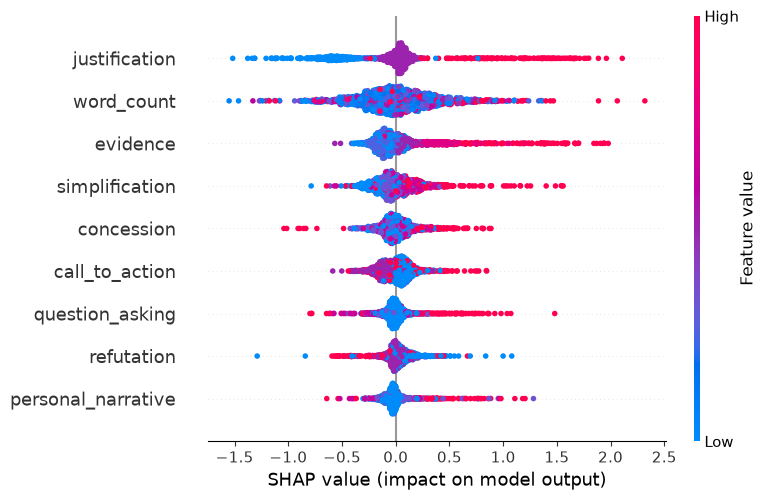

In [17]:
import shap
import matplotlib.pyplot as plt

selected_pipe = clone(make_selected_pipe())
selected_pipe.fit(wa_df.loc[train_idx, BEST_FEATURE_COLS], y_train)

X_test_scaled = pd.DataFrame(
    selected_pipe.named_steps['scaler'].transform(wa_df.loc[test_idx, BEST_FEATURE_COLS]),
    columns=BEST_FEATURE_COLS, index=test_idx,
)
explainer = shap.TreeExplainer(selected_pipe.named_steps['clf'])
shap_values = explainer(X_test_scaled)

shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()


### Mann-Whitney U Effect Sizes

Unchanged from `07`: rank-biserial correlation per strategy (winner vs loser), FDR-corrected (Benjamini-Hochberg) across the 8 simultaneous tests. Run on the full scored population (both splits combined) — this is a descriptive population comparison, not a fitted model, so it doesn't need a train/test split.

In [18]:
from scipy.stats import mannwhitneyu

# Unchanged from 07_strategy_interpretation.ipynb
def benjamini_hochberg(p_values):
    """Benjamini-Hochberg FDR-adjusted p-values - avoids adding statsmodels as a dependency
    for a single well-known procedure."""
    p = np.asarray(p_values)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order] * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(ranked[::-1])[::-1]
    result = np.empty(m)
    result[order] = np.clip(adjusted, 0, 1)
    return result

def strategy_effect_sizes(df):
    """Mann-Whitney U + rank-biserial effect size per strategy, FDR-corrected across the 8 tests."""
    convincing = df[df['is_convincing'] == 1]
    non_convincing = df[df['is_convincing'] == 0]

    rows = {}
    for strategy in STRATEGY_NAMES:
        conv_scores = convincing[strategy]
        non_conv_scores = non_convincing[strategy]
        u_stat, p_value = mannwhitneyu(conv_scores, non_conv_scores, alternative='two-sided')
        n1, n2 = len(conv_scores), len(non_conv_scores)
        rank_biserial = 2 * u_stat / (n1 * n2) - 1
        rows[strategy] = {
            'mean (winner)': conv_scores.mean(),
            'mean (loser)': non_conv_scores.mean(),
            'rank-biserial r': rank_biserial,
            'p-value': p_value,
        }

    result = pd.DataFrame(rows).T
    result['p-value (FDR)'] = benjamini_hochberg(result['p-value'].values)
    result['significant (FDR < 0.05)'] = result['p-value (FDR)'] < 0.05
    return result.sort_values('rank-biserial r', ascending=False)

effect_sizes_full = strategy_effect_sizes(wa_df)
effect_sizes_full.round(4)


,mean (winner),mean (loser),rank-biserial r,p-value,p-value (FDR),significant (FDR < 0.05)
justification,3.9469,3.7011,0.1962,0.0000,0.0000,True
evidence,2.4760,2.1453,0.1467,0.0000,0.0000,True
simplification,2.3906,2.1761,0.1105,0.0000,0.0000,True
refutation,3.7710,3.6374,0.0949,0.0000,0.0000,True
concession,2.1488,2.0458,0.0542,0.0000,0.0000,True
call_to_action,1.8706,1.8104,0.0305,0.0110,0.0147,True
personal_narrative,1.6097,1.5400,0.0224,0.0273,0.0312,True
question_asking,1.5353,1.5706,-0.0135,0.1734,0.1734,False


## Test-Retest: Are the WA Scores Reliable?

Before treating the comparisons above as a genuine dataset difference rather than noise, this checks something specific: `05`'s own validation (§2.3) flagged `refutation` and `justification` as the two strategies hardest to calibrate consistently — even against the LLM's own repeated judgment, `refutation` was the weakest of all 8 on test-retest (63.8% exact match). The most surprising finding on WA so far involves exactly these two strategies (`justification` overtaking `refutation` as the standout, above). Re-scores a random sample of already-scored WA comments completely independently, same rubric and prompt, and compares the two passes — mirroring `05`'s own test-retest design exactly (same n=200, same metrics), so the WA reliability numbers are directly comparable to the ones already on record for my dataset.

In [13]:
retest_sample = wa_df.sample(n=200, random_state=42)[['original_post', 'thread_text', 'final_comment']].copy()
print(f'{len(retest_sample)} comments sampled for independent re-scoring')


200 comments sampled for independent re-scoring


In [14]:
WA_RETEST_CHECKPOINT_PATH = '../results/wa_strategy_scores_retest_checkpoint.csv'

retest_scores_df = common_functions.score_comments_by_thread(
    retest_sample, STRATEGY_NAMES, get_strategy_scores_batch_op, WA_RETEST_CHECKPOINT_PATH, PROMPT_HASH_V2)


Loaded checkpoint: 198 rows match the current prompt, 0 row(s) were scored under a different prompt version and will be re-scored, 2 row(s) were never scored yet


Done: 200 / 200 scored


In [15]:
retest_valid = retest_scores_df[retest_scores_df[STRATEGY_NAMES[0]].notna()]
print(f'{len(retest_valid)} / {len(retest_scores_df)} retest rows got a parseable response both times')

original_scores = wa_df.loc[retest_valid.index, STRATEGY_NAMES]
retest_only = retest_valid[STRATEGY_NAMES]
diff = (retest_only - original_scores).astype(float)

wa_retest_agreement = pd.DataFrame({
    'exact_match_pct': (diff == 0).mean() * 100,
    'within_1_pct': (diff.abs() <= 1).mean() * 100,
    'mean_abs_diff': diff.abs().mean(),
}).sort_values('exact_match_pct')
wa_retest_agreement.round(2)


200 / 200 retest rows got a parseable response both times


,exact_match_pct,within_1_pct,mean_abs_diff
call_to_action,75.5,99.5,0.25
refutation,76.5,100.0,0.24
concession,77.0,99.5,0.24
simplification,77.0,100.0,0.23
evidence,77.5,99.5,0.23
justification,80.5,100.0,0.20
question_asking,89.0,99.5,0.12
personal_narrative,94.5,100.0,0.06


**Reassuring, not concerning: `refutation` is *more* reliable on WA than it was on my dataset, not less.** `05`'s own test-retest on my dataset (n=199) found `refutation` the weakest of all 8 strategies (63.8% exact match, 95.5% within ±1, mean absolute difference 0.41). On WA, `refutation` scores 76.5% exact / 100% within ±1 / 0.24 mean difference - tighter agreement on every measure. All 8 strategies are more consistent on WA than their counterparts in my dataset (exact match 75.5-94.5% here vs. 63.8-86.9% on my dataset), plausibly because WA's comments are both longer on average (236 vs. 78-216 words) and already pre-filtered by the original pair-task construction to be substantive arguments, giving the LLM more to work with. This rules out the most likely alternative explanation for `justification` overtaking `refutation` on WA: it is not that `refutation`'s scores became noisier here. The reversal in section 2's findings looks like a genuine property of WA's data, not a scoring-reliability artifact.

## Length-Control Check: Does `justification` Look Strong Before Length Control and Weaken After?

WA's structure does allow a length-control check: unlike the pairing itself (topic-matched, not length-matched), nothing in WA's construction controls for `word_count`, and the point-biserial correlation above (r=0.1516) confirms a real, if on this dataset comparatively modest, length confound exists here too. Reuses `06`'s exact decile-matching procedure (bin convincing comments' `word_count` into deciles, sample a length-matched number of non-convincing comments per bin) to build a strict 1:1 length-matched sample, then repeats both the model-based comparison above and the Mann-Whitney effect sizes on it.

In [19]:
# Unchanged procedure from 06_strategy_ablation.ipynb's Length-Controlled Benchmark (decile-matching)
n_bins = 10
conv_df = wa_df[wa_df['is_convincing'] == 1].copy()
nonconv_df = wa_df[wa_df['is_convincing'] == 0].copy()

bin_edges = pd.qcut(conv_df['word_count'], n_bins, duplicates='drop', retbins=True)[1]
conv_df['length_bin'] = pd.cut(conv_df['word_count'], bins=bin_edges, include_lowest=True)
nonconv_df['length_bin'] = pd.cut(nonconv_df['word_count'], bins=bin_edges, include_lowest=True)

matched_parts = []
for bin_label, group in conv_df.groupby('length_bin', observed=True):
    pool = nonconv_df[nonconv_df['length_bin'] == bin_label]
    take_n = min(len(group), len(pool))
    if take_n > 0:
        matched_parts.append(pool.sample(n=take_n, random_state=42))

matched_nonconv_df = pd.concat(matched_parts) if matched_parts else nonconv_df.iloc[:0]
wa_df_matched = pd.concat([conv_df, matched_nonconv_df]).drop(columns='length_bin').sort_index()

r_matched, p_matched = pointbiserialr(wa_df_matched['is_convincing'], wa_df_matched['word_count'])
print(f'Strict 1:1 length-matched sample: {len(wa_df_matched)} comments '
      f'({int(wa_df_matched["is_convincing"].sum())} winners)')
print(f'word_count correlation after matching: r={r_matched:.4f}  (unmatched: r={r:.4f})')
print(wa_df_matched["split"].value_counts())


Strict 1:1 length-matched sample: 7710 comments (4235 winners)
word_count correlation after matching: r=0.1168  (unmatched: r=0.1516)
split
train      6272
heldout    1438
Name: count, dtype: int64


In [20]:
def evaluate_cols_on_sample(sample_df, cols):
    """Same fixed-architecture evaluation as evaluate_cols(), generalized to any sample's own
    native train/heldout split - used for the length-matched sample here."""
    tr_idx = sample_df.index[sample_df['split'] == 'train']
    te_idx = sample_df.index[sample_df['split'] == 'heldout']
    y_tr, y_te = sample_df.loc[tr_idx, 'is_convincing'], sample_df.loc[te_idx, 'is_convincing']

    pipe = clone(make_selected_pipe())
    pipe.fit(sample_df.loc[tr_idx, cols], y_tr)
    proba = pipe.predict_proba(sample_df.loc[te_idx, cols])[:, 1]
    return average_precision_score(y_te, proba), y_te.mean(), len(tr_idx), len(te_idx)

def evaluate_cols_on_sample_order_robust(sample_df, cols, n_repeats=8, seed=0):
    rng = random.Random(seed)
    pr_aucs = []
    no_skill = None
    for _ in range(n_repeats):
        shuffled = list(cols)
        rng.shuffle(shuffled)
        pr, ns, n_tr, n_te = evaluate_cols_on_sample(sample_df, shuffled)
        pr_aucs.append(pr)
        no_skill = ns
    return np.mean(pr_aucs), np.std(pr_aucs), no_skill

length_control_rows = []
for sample_name, sample_df in [('Full scored population', wa_df), ('Length-matched', wa_df_matched)]:
    for feature_name, cols in [('word_count only', ['word_count']),
                                 ('strategy scores + word_count', BEST_FEATURE_COLS)]:
        mean_pr, std_pr, ns = evaluate_cols_on_sample_order_robust(sample_df, cols)
        length_control_rows.append({
            'sample': sample_name, 'features': feature_name,
            'n': len(sample_df), 'no-skill baseline': ns,
            'PR-AUC mean': mean_pr, 'PR-AUC std': std_pr,
            'lift over no-skill': mean_pr - ns,
        })

length_control_df = pd.DataFrame(length_control_rows).set_index(['sample', 'features']).round(4)
length_control_df


n  no-skill baseline  \
sample                 features                                                
Full scored population word_count only               8096             0.5291   
                       strategy scores + word_count  8096             0.5291   
Length-matched         word_count only               7710             0.5563   
                       strategy scores + word_count  7710             0.5563   

                                                     PR-AUC mean  PR-AUC std  \
sample                 features                                                
Full scored population word_count only                    0.5767      0.0000   
                       strategy scores + word_count       0.5814      0.0058   
Length-matched         word_count only                    0.5774      0.0000   
                       strategy scores + word_count       0.6019      0.0028   

                                                     lift over no-skill  
sample                 features                                          
Full scored population word_count only                           0.0476  
                       strategy scores + word_count              0.0523  
Length-matched         word_count only                           0.0211  
                       strategy scores + word_count              0.0455

In [21]:
effect_sizes_matched = strategy_effect_sizes(wa_df_matched)

effect_size_comparison = pd.DataFrame({
    'rank-biserial r (full population)': effect_sizes_full['rank-biserial r'],
    'significant, full (FDR < 0.05)': effect_sizes_full['significant (FDR < 0.05)'],
    'rank-biserial r (length-matched)': effect_sizes_matched['rank-biserial r'],
    'significant, matched (FDR < 0.05)': effect_sizes_matched['significant (FDR < 0.05)'],
}).sort_values('rank-biserial r (length-matched)', ascending=False)
effect_size_comparison.round(4)


,rank-biserial r (full population),"significant, full (FDR < 0.05)",rank-biserial r (length-matched),"significant, matched (FDR < 0.05)"
justification,0.1962,True,0.1648,True
evidence,0.1467,True,0.1297,True
simplification,0.1105,True,0.0888,True
refutation,0.0949,True,0.0735,True
concession,0.0542,True,0.0328,True
call_to_action,0.0305,True,0.0131,False
personal_narrative,0.0224,True,0.0111,False
question_asking,-0.0135,False,-0.0161,False


**Conclusion: unlike on my dataset, `justification` does *not* weaken after length control on WA.** It starts as the single largest Mann-Whitney effect size (r=0.1962) and stays the single largest after strict 1:1 length-matching (r=0.1648, 84.0% retained) - barely moving, let alone collapsing the way it did on my dataset, where its SHAP importance dropped from the model's 3rd most influential feature to one of its least influential under the same kind of matching (`07`).

More broadly, the strategy signal survives length control here too, though the confound it's surviving is milder to begin with: WA's own `word_count` correlation starts at r=0.1516 (vs. my dataset's r=0.3716) and only drops to r=0.1168 (77.0% retained) under strict 1:1 matching - a much smaller confound to control for than on my dataset. 5 of the 8 strategies stay statistically significant after matching: `justification`, `evidence`, `simplification`, and `refutation` each retain 77-88% of their effect size, while `concession` retains much less (60.5%); `call_to_action`, `personal_narrative`, and `question_asking` lose significance entirely. The model-based view agrees - `word_count` alone loses more than half its predictive lift under matching (0.0476 → 0.0211, 44.3% retained), while the strategy-inclusive model keeps the large majority of its lift (0.0523 → 0.0455, 87.0% retained), mirroring the same qualitative pattern `06` found on my dataset (`word_count`'s lift retained only 18% there vs. the strategy-inclusive model's 84%) - just with a less dramatic length confound here to begin with.

## Does the Reduced Model Stay Competitive?

`07`'s pruning check, repeated here and extended to cover all five strategies not in the robust core: tests dropping `question_asking`, `personal_narrative`, `evidence`, `concession`, and `call_to_action` individually, then cumulatively, building up to the full removal of all five - the predetermined 4-column `robust core` (`refutation`, `justification`, `simplification`, `word_count`). The robust core itself isn't re-derived on WA (no tuning on WA, per the plan); it's carried over unchanged from `07`'s own criterion on this project's own data: the only strategies that stayed statistically significant both before *and* after length-matching were `refutation`, `justification`, and `simplification` - `concession` and `call_to_action` were significant in the full population but lost significance once length was controlled for, the same fate as `evidence`. Compared against the same order-noise band used throughout (combined SD across the two configurations being compared).

In [ ]:
pruning_configs = {
    'all 9 strategies + word_count':                                       BEST_FEATURE_COLS,
    '- question_asking':                                                   [c for c in BEST_FEATURE_COLS if c != 'question_asking'],
    '- personal_narrative':                                                [c for c in BEST_FEATURE_COLS if c != 'personal_narrative'],
    '- evidence':                                                          [c for c in BEST_FEATURE_COLS if c != 'evidence'],
    '- concession':                                                        [c for c in BEST_FEATURE_COLS if c != 'concession'],
    '- call_to_action':                                                    [c for c in BEST_FEATURE_COLS if c != 'call_to_action'],
    '- question_asking, personal_narrative':                               [c for c in BEST_FEATURE_COLS if c not in ('question_asking', 'personal_narrative')],
    '- question_asking, personal_narrative, evidence':                     [c for c in BEST_FEATURE_COLS if c not in ('question_asking', 'personal_narrative', 'evidence')],
    '- question_asking, personal_narrative, evidence, concession':         [c for c in BEST_FEATURE_COLS if c not in ('question_asking', 'personal_narrative', 'evidence', 'concession')],
    'robust core (refutation, justification, simplification, word_count)': ROBUST_CORE_COLS,
}

pruning_results = {name: evaluate_cols_order_robust(cols) for name, cols in pruning_configs.items()}
pruning_df = pd.DataFrame(pruning_results).T[['PR-AUC mean', 'PR-AUC std', 'ROC-AUC mean', 'lift over no-skill']]

baseline_mean = pruning_df.loc['all 9 strategies + word_count', 'PR-AUC mean']
baseline_std = pruning_df.loc['all 9 strategies + word_count', 'PR-AUC std']
pruning_df['Delta PR-AUC vs baseline'] = (pruning_df['PR-AUC mean'] - baseline_mean).round(4)
combined_std = pruning_df['PR-AUC std'] + baseline_std
pruning_df['Robust to order?'] = pruning_df['Delta PR-AUC vs baseline'].abs() > combined_std
pruning_df.round(4)

                                                    PR-AUC mean  PR-AUC std  \
all 9 strategies + word_count                            0.5814      0.0058   
- question_asking                                        0.5853      0.0038   
- personal_narrative                                     0.5771      0.0043   
- evidence                                               0.5825      0.0023   
- concession                                             0.5892      0.0042   
- call_to_action                                         0.5937      0.0063   
- question_asking, personal_narrative                    0.5889      0.0032   
- question_asking, personal_narrative, evidence          0.5868      0.0044   
- question_asking, personal_narrative, evidence...       0.5860      0.0014   
robust core (refutation, justification, simplif...       0.5919      0.0026   

                                                    ROC-AUC mean  lift over no-skill  \
all 9 strategies + word_count             

**The single best configuration in this table isn't the robust core - it's just dropping `call_to_action` alone.** `- call_to_action` (8 columns: all strategies except `call_to_action`, plus `word_count`) reaches PR-AUC 0.5937, higher than the robust core's 0.5919, and is the only other configuration besides the robust core whose gain over the full 9-column baseline clears the order-noise band (delta 0.0124 vs. a combined SD of roughly 0.0121). It also beats the robust core on pairwise accuracy (59.10% vs. 58.68%). `- concession` alone is a smaller, not-robust-to-order improvement (0.5892); dropping it as part of the cumulative build-up toward the robust core doesn't change that story - the 4-column config (`- question_asking, personal_narrative, evidence, concession`) actually dips slightly below the 3-column version before it (0.5860 vs. 0.5868).

So on WA specifically, `call_to_action` looks like the single strategy doing the most harm, more so than any of the three strategies `07`'s own criterion identified (`question_asking`, `personal_narrative`, `evidence`) - but the robust core still isn't a bad choice: it's the second-best configuration tested, well within noise of the new best one, and it's the config that's principled by a fixed, pre-registered criterion from `07` rather than something selected by scanning this table for the best WA result (which would be exactly the kind of tuning-on-WA the plan rules out).

## Pairwise Accuracy — Comparable to the Literature's Benchmark Numbers

Every comparison above frames WA the same way this project's own data is framed throughout `04`-`07`: each comment is scored independently, and PR-AUC is computed by ranking all heldout comments against each other. That is *not* the task Tan et al. (2016) or Labruna, Modzelewski, Satta & Da San Martino (2026) report accuracy on — their benchmark is the **pairwise task**: within each winner/loser pair, predict whichever of the two has the higher score as the winner, and measure accuracy over pairs. Reported reference points from Labruna et al. (2026), Table 1, for context (not a like-for-like comparison target to chase — WA scored here is 8,106 single comments reused across this project's own architecture, not their LLM-native pipeline): Independent Scoring 53.78-56.66%, MS-PS-AVG 60.59-62.83%, best reported (MS-PS-MLP + OpenAI-o3) 64.53%.

This reconstructs the full pair list directly from the raw corpus (not from `wa_df`'s deduplicated `pair_id` column, which keeps only one `pair_id` for the ~420 comments that serve as the closest topical match to more than one winning thread) and restricts to the 805 pairs in the native heldout split that still have both sides scored — 2 fewer than the literature's reported 807, a direct consequence of the 4 heldout comments already dropped above for an unparseable Gemini response (each unscored comment removes any pair it belongs to). For each feature-set config already fit above, accuracy = the fraction of heldout pairs where the model's predicted probability is higher for the actual winner than for the actual loser (ties split as 0.5), averaged over the same 8 column-order shuffles used throughout this notebook.

In [23]:
pair_table = {}
with open(os.path.join(WA_CORPUS_PATH, 'utterances.jsonl')) as f:
    for line in f:
        u = json.loads(line)
        meta = u['meta']
        if meta['success'] is None or u['reply-to'] != u['root']:
            continue
        for pid in meta['pair_ids']:
            pair_table.setdefault(pid, {})[meta['success']] = u['id']

comment_split = wa_df.set_index('comment_id')['split']
pairs_df = pd.DataFrame([
    {'pair_id': pid, 'winner_id': sides[1], 'loser_id': sides[0]}
    for pid, sides in pair_table.items() if 0 in sides and 1 in sides
])
pairs_df['split'] = pairs_df['winner_id'].map(comment_split)
assert len(pairs_df) == 4263
heldout_pairs = pairs_df[pairs_df['split'] == 'heldout'].reset_index(drop=True)
print(f'{len(pairs_df)} total pairs reconstructed, {len(heldout_pairs)} in the heldout split')

id_to_idx = pd.Series(wa_df.index.values, index=wa_df['comment_id'].values)

def pairwise_accuracy(cols):
    pipe = clone(make_selected_pipe())
    pipe.fit(wa_df.loc[train_idx, cols], y_train)
    proba_test = pd.Series(pipe.predict_proba(wa_df.loc[test_idx, cols])[:, 1], index=test_idx)

    winner_proba = proba_test.loc[id_to_idx.loc[heldout_pairs['winner_id']].values].values
    loser_proba = proba_test.loc[id_to_idx.loc[heldout_pairs['loser_id']].values].values
    correct = (winner_proba > loser_proba).astype(float) + 0.5 * (winner_proba == loser_proba)
    return correct.mean()

def pairwise_accuracy_order_robust(cols, n_repeats=8, seed=0):
    rng = random.Random(seed)
    accs = []
    for _ in range(n_repeats):
        shuffled = list(cols)
        rng.shuffle(shuffled)
        accs.append(pairwise_accuracy(shuffled))
    return np.mean(accs), np.std(accs)

# Also include '- call_to_action' alone here, not just in the PR-AUC pruning table above -
# it beat the robust core there, worth checking whether that holds on the metric that matters
# most for WA's actual task too.
pairwise_accuracy_configs = dict(feature_set_configs)
pairwise_accuracy_configs['- call_to_action'] = [c for c in BEST_FEATURE_COLS if c != 'call_to_action']

pairwise_accuracy_rows = {}
for name, cols in pairwise_accuracy_configs.items():
    mean_acc, std_acc = pairwise_accuracy_order_robust(cols)
    pairwise_accuracy_rows[name] = {'pairwise accuracy mean': mean_acc, 'pairwise accuracy std': std_acc}

pairwise_accuracy_df = pd.DataFrame(pairwise_accuracy_rows).T
pairwise_accuracy_df['chance baseline'] = 0.5
pairwise_accuracy_df.round(4)


4263 total pairs reconstructed, 805 in the heldout split


,pairwise accuracy mean,pairwise accuracy std,chance baseline
word_count only,0.5559,0.0000,0.5
strategy scores only,0.5727,0.0035,0.5
strategy scores + word_count,0.5809,0.0095,0.5
"robust core (refutation, justification, simplification, word_count)",0.5868,0.0064,0.5
- call_to_action,0.5910,0.0095,0.5


## Summary — External Validation Findings

Answering the five questions this notebook set out to check, in order:

**1. Do the 8 strategy scores add information beyond `word_count` on WA too?** Yes, though the two metrics tell slightly different versions of the story. By pairwise accuracy (the metric comparable to the literature) every strategy-containing configuration beats `word_count` alone: 55.59% (`word_count` only) → 57.27% (strategy scores only) → 58.09% (strategy scores + `word_count`) → 58.68% (robust core). By PR-AUC, strategy scores alone (0.5967) actually edge out strategy scores + `word_count` (0.5814) — unlike on my dataset, where combining the two was always the best option. `word_count`'s own correlation with `is_convincing` is much weaker on WA (r=0.1516) than on my dataset (r=0.3716, `04.2`), so there's less for the combination to gain from here, and in the PR-AUC view combining them costs a little rather than adding.

**2. Does `refutation` remain the standout, most-consistent strategy?** No — this is the clearest divergence from my dataset. A natural worry: is this just `refutation` being scored less reliably on WA, given `05` already flagged it as the hardest strategy to calibrate on my dataset? No - a dedicated test-retest check (n=200, same design as `05`'s own) found `refutation` is actually *more* consistent on WA (76.5% exact match, 100% within ±1) than it was on my dataset (63.8%/95.5%, the weakest of all 8 strategies there). All 8 strategies score tighter on WA than on my dataset. The reversal looks like a real property of the data, not noise. On WA, **`justification`** is the standout by every measure: the top SHAP feature (above even `word_count`), and the largest Mann-Whitney effect size (r=0.1962), both well ahead of `refutation` (4th by effect size, r=0.0949, and near the bottom of the SHAP ranking). On my dataset, the ranking was reversed — `refutation` was the standout (mean |SHAP| 0.603, 1.5x `justification`'s 0.416) and the one strategy that held up best under length control.

**3. Does `justification` again look strong before length control and weaken after, same as on my dataset?** No — this doesn't replicate either, and it's the flip side of finding 2. On my dataset, `justification`'s SHAP importance nearly vanished after length-matching, consistent with a strategy that was largely riding on comment length. On WA, `justification` stays the single largest Mann-Whitney effect size *after* length-matching too (r=0.1648, 84.0% of its full-population effect retained) — not a length proxy here. Four other strategies also remain significant after matching: `evidence` (88.4% of its effect retained), `simplification` (80.4%), `refutation` (77.4%), and `concession` — though `concession` retains much less of its effect than the other three (60.5%, r=0.0542→0.0328), the weakest-surviving case. `call_to_action`, `personal_narrative`, and `question_asking` lose significance under matching entirely, consistent with the same pattern already observed on my dataset, where weaker strategies are more length-dependent.

**4. Does the reduced model (`refutation` + `justification` + `simplification` + `word_count`) stay competitive?** Yes, though it isn't the single best configuration tested. The 4-column robust core reaches PR-AUC 0.5919 and pairwise accuracy 58.68%, comfortably ahead of the full 9-column baseline (0.5814 / 58.09%) and robust to column-order noise. But simply dropping `call_to_action` alone (8 columns) does slightly better on both metrics - PR-AUC 0.5937, pairwise accuracy 59.10% - and is the only *other* configuration in the pruning table that also clears the order-noise band. On WA, `call_to_action` looks like the single strategy doing the most harm to the model, more so than any of the three my dataset's own criterion flagged (`question_asking`, `personal_narrative`, `evidence`). The robust core's case still stands, though: it's the second-best configuration tested, within noise of the best one, and it's fixed in advance by a principled criterion from `07`, based on this project's own data, rather than picked by scanning this table for WA's best result - which would itself be the kind of tuning-on-WA the plan rules out. It's also not the single highest PR-AUC in the notebook overall either way - `strategy scores only` (no `word_count`, finding 1) reaches 0.5967, though that gap (0.0048) is itself smaller than the two configurations' combined order-noise band (0.0054), just another noise-sized tie.

**5. Does the strategy effect hold up under a length-control check?** Yes. WA's own `word_count` correlation drops from r=0.1516 to r=0.1168 under strict 1:1 length-matching (7,710 comments), and despite that, five of the eight strategies remain statistically significant — four of them (`justification`, `evidence`, `simplification`, `refutation`) retaining most of their effect size, and one (`concession`) retaining substantially less (see finding 3) — the strategy signal here is not simply riding on comment length, matching the core finding already established on my dataset, even though *which* strategy carries that signal is different.

**Overall read:** this is a partial, not a full, replication, and that partiality is itself informative — it shows precisely which of the project's conclusions generalize beyond its own data, and which don't. The project's two most "structural" conclusions generalize cleanly to an independent dataset - built by different researchers, using a different construction methodology, from the same underlying CMV subreddit: strategy scores carry real signal beyond length, and a small 4-feature model built from this project's own strategy set is competitive with every larger combination tried. One genuinely new discovery here, though: on WA, `call_to_action` is the single most harmful strategy to the model - dropping it alone (finding 4) beats the robust core on both PR-AUC and pairwise accuracy, more so than any of the three strategies this project's own criterion from `07` had already flagged as weak. But the specific claim that `refutation` is *the* persuasion strategy, and that `justification` is specifically a length-confounded one, does not hold up on WA — there, `justification` takes `refutation`'s role as the most robust, length-independent signal. Comparable to the literature's own benchmark too: the robust core's 58.68% pairwise accuracy sits above the "Independent Scoring" baselines reported by Labruna et al. (53.78-56.66%) and below their full MS-PS methods (60.59-64.53%) — respectable for a model using none of this project's engineered features and no tuning against WA at all.